In [1]:
# ─── Cell 1: Setup & Imports ───────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported!')

✅ All libraries imported!


In [2]:
# ─── Cell 2: Load Dataset & Parse Dates ────────────────────────────────────
df = pd.read_csv('train.csv', encoding='latin1')

# Parse dates properly — dayfirst=True because format is DD/MM/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

print(f'📦 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📋 Columns: {df.columns.tolist()}')
print(f'\n📅 Date range: {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'\n🔎 Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\n🔍 First 5 rows:')
df.head(5)

📦 Shape: 9800 rows × 18 columns

📋 Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

📅 Date range: 2015-01-03 → 2018-12-30

🔎 Missing values:
Postal Code    11
dtype: int64

🔍 First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# ─── Cell 3: Extract Time Features ─────────────────────────────────────────
# Extract useful time components from Order Date
df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['Week']      = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Order Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Quarter']   = df['Order Date'].dt.quarter

# Map months to seasons
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
               3:'Spring', 4:'Spring', 5:'Spring',
               6:'Summer', 7:'Summer', 8:'Summer',
               9:'Autumn', 10:'Autumn', 11:'Autumn'}
df['Season'] = df['Month'].map(season_map)

# Calculate shipping time in days
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days

print('✅ Time features added!')
print(f'\nNew columns: Year, Month, Week, DayOfWeek, Quarter, Season, ShipDays')
print(f'\nSample — Season distribution:\n{df["Season"].value_counts().to_string()}')
print(f'\nSample — ShipDays stats:')
print(df['ShipDays'].describe().round(2).to_string())

✅ Time features added!

New columns: Year, Month, Week, DayOfWeek, Quarter, Season, ShipDays

Sample — Season distribution:
Season
Autumn    3612
Summer    2081
Spring    2062
Winter    2045

Sample — ShipDays stats:
count    9800.00
mean        3.96
std         1.75
min         0.00
25%         3.00
50%         4.00
75%         5.00
max         7.00


In [4]:
# ─── Cell 4: Answer the 4 Business Questions ────────────────────────────────

# Q1: Which category generates highest total revenue?
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print('Q1 — Total Revenue by Category:')
for cat, val in cat_rev.items():
    print(f'   {cat:<20} ${val:>10,.0f}')
print(f'\n   ✅ Answer: {cat_rev.idxmax()} generates the highest revenue (${cat_rev.max():,.0f})')

# Q2: Which region has most consistent sales growth?
region_yr = df.groupby(['Region','Year'])['Sales'].sum().unstack()
print(f'\nQ2 — Sales by Region & Year:')
print(region_yr.round(0).to_string())
# Calculate year-over-year growth for each region
region_growth = region_yr.pct_change(axis=1).mean(axis=1).mul(100).round(2)
print(f'\n   Average YoY Growth Rate by Region:')
for region, growth in region_growth.sort_values(ascending=False).items():
    print(f'   {region:<12} {growth:.2f}% avg annual growth')
print(f'\n   ✅ Answer: {region_growth.idxmax()} has most consistent growth')

# Q3: Avg ship time by region
ship_region = df.groupby('Region')['ShipDays'].mean().round(2).sort_values(ascending=False)
print(f'\nQ3 — Average Ship Days by Region:')
for region, days in ship_region.items():
    print(f'   {region:<12} {days} days')
print(f'\n   ✅ Answer: {ship_region.idxmax()} takes longest ({ship_region.max()} days avg)')

# Q4: Monthly seasonality — do same months spike every year?
monthly_avg = df.groupby('Month')['Sales'].mean().round(0)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print(f'\nQ4 — Average Sales per Order by Month:')
for m, val in monthly_avg.items():
    bar = '█' * int(val/50)
    print(f'   {month_names[m]}: ${val:>6,.0f}  {bar}')
top3 = monthly_avg.nlargest(3).index.tolist()
print(f'\n   ✅ Answer: Months {[month_names[m] for m in top3]} consistently spike across years')

Q1 — Total Revenue by Category:
   Technology           $   827,456
   Furniture            $   728,659
   Office Supplies      $   705,422

   ✅ Answer: Technology generates the highest revenue ($827,456)

Q2 — Sales by Region & Year:
Year         2015      2016      2017      2018
Region                                         
Central  102921.0  102425.0  145674.0  141627.0
East     127653.0  153225.0  178512.0  210129.0
South    103375.0   70076.0   93536.0  122165.0
West     145908.0  133710.0  182471.0  248131.0

   Average YoY Growth Rate by Region:
   West         21.36% avg annual growth
   East         18.08% avg annual growth
   Central      12.99% avg annual growth
   South        10.62% avg annual growth

   ✅ Answer: West has most consistent growth

Q3 — Average Ship Days by Region:
   Central      4.07 days
   South        3.96 days
   West         3.93 days
   East         3.91 days

   ✅ Answer: Central takes longest (4.07 days avg)

Q4 — Average Sales per Order by Mon

In [5]:
# ─── Cell 5: Aggregate into Weekly & Monthly Series ─────────────────────────

# Monthly aggregation — sum all sales per month
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()
monthly = monthly.sort_index()

# Weekly aggregation — sum all sales per week
weekly = df.groupby(df['Order Date'].dt.to_period('W'))['Sales'].sum()
weekly.index = weekly.index.to_timestamp()
weekly = weekly.sort_index()

print('✅ Aggregations complete!')
print(f'\n📅 Monthly series — {len(monthly)} data points:')
print(f'   Range: {monthly.index[0].date()} → {monthly.index[-1].date()}')
print(f'   Min monthly sales : ${monthly.min():>10,.0f}')
print(f'   Max monthly sales : ${monthly.max():>10,.0f}')
print(f'   Avg monthly sales : ${monthly.mean():>10,.0f}')

print(f'\n📅 Weekly series — {len(weekly)} data points:')
print(f'   Range: {weekly.index[0].date()} → {weekly.index[-1].date()}')
print(f'   Min weekly sales  : ${weekly.min():>10,.0f}')
print(f'   Max weekly sales  : ${weekly.max():>10,.0f}')
print(f'   Avg weekly sales  : ${weekly.mean():>10,.0f}')

print(f'\n📊 Monthly sales preview (first 6 months):')
for date, val in monthly.head(6).items():
    print(f'   {date.strftime("%b %Y")}: ${val:>10,.0f}')

✅ Aggregations complete!

📅 Monthly series — 48 data points:
   Range: 2015-01-01 → 2018-12-01
   Min monthly sales : $     4,520
   Max monthly sales : $   117,938
   Avg monthly sales : $    47,115

📅 Weekly series — 209 data points:
   Range: 2014-12-29 → 2018-12-24
   Min weekly sales  : $       225
   Max weekly sales  : $    37,704
   Avg weekly sales  : $    10,821

📊 Monthly sales preview (first 6 months):
   Jan 2015: $    14,206
   Feb 2015: $     4,520
   Mar 2015: $    55,206
   Apr 2015: $    27,907
   May 2015: $    23,644
   Jun 2015: $    34,323


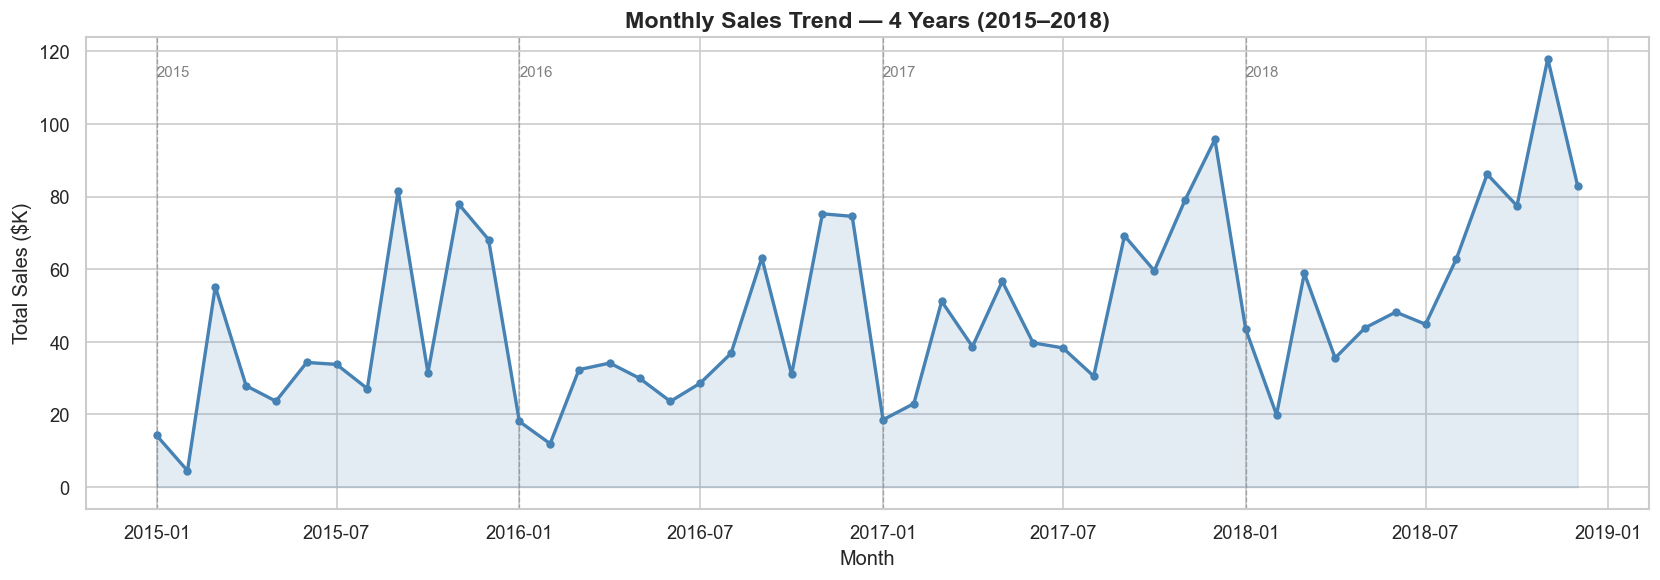

✅ Chart 1 saved → charts/chart1_monthly_trend.png


In [6]:
# ─── Cell 6: Monthly Sales Trend Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly.index, monthly.values / 1000,
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly.values / 1000,
                alpha=0.15, color='steelblue')

# Add vertical lines at each year boundary
for yr in [2015, 2016, 2017, 2018]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'),
               color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.Timestamp(f'{yr}-01-01'),
            monthly.values.max() / 1000 * 0.96,
            str(yr), fontsize=9, color='gray')

ax.set_title('Monthly Sales Trend — 4 Years (2015–2018)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($K)')

plt.tight_layout()
plt.savefig('charts/chart1_monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 1 saved → charts/chart1_monthly_trend.png')

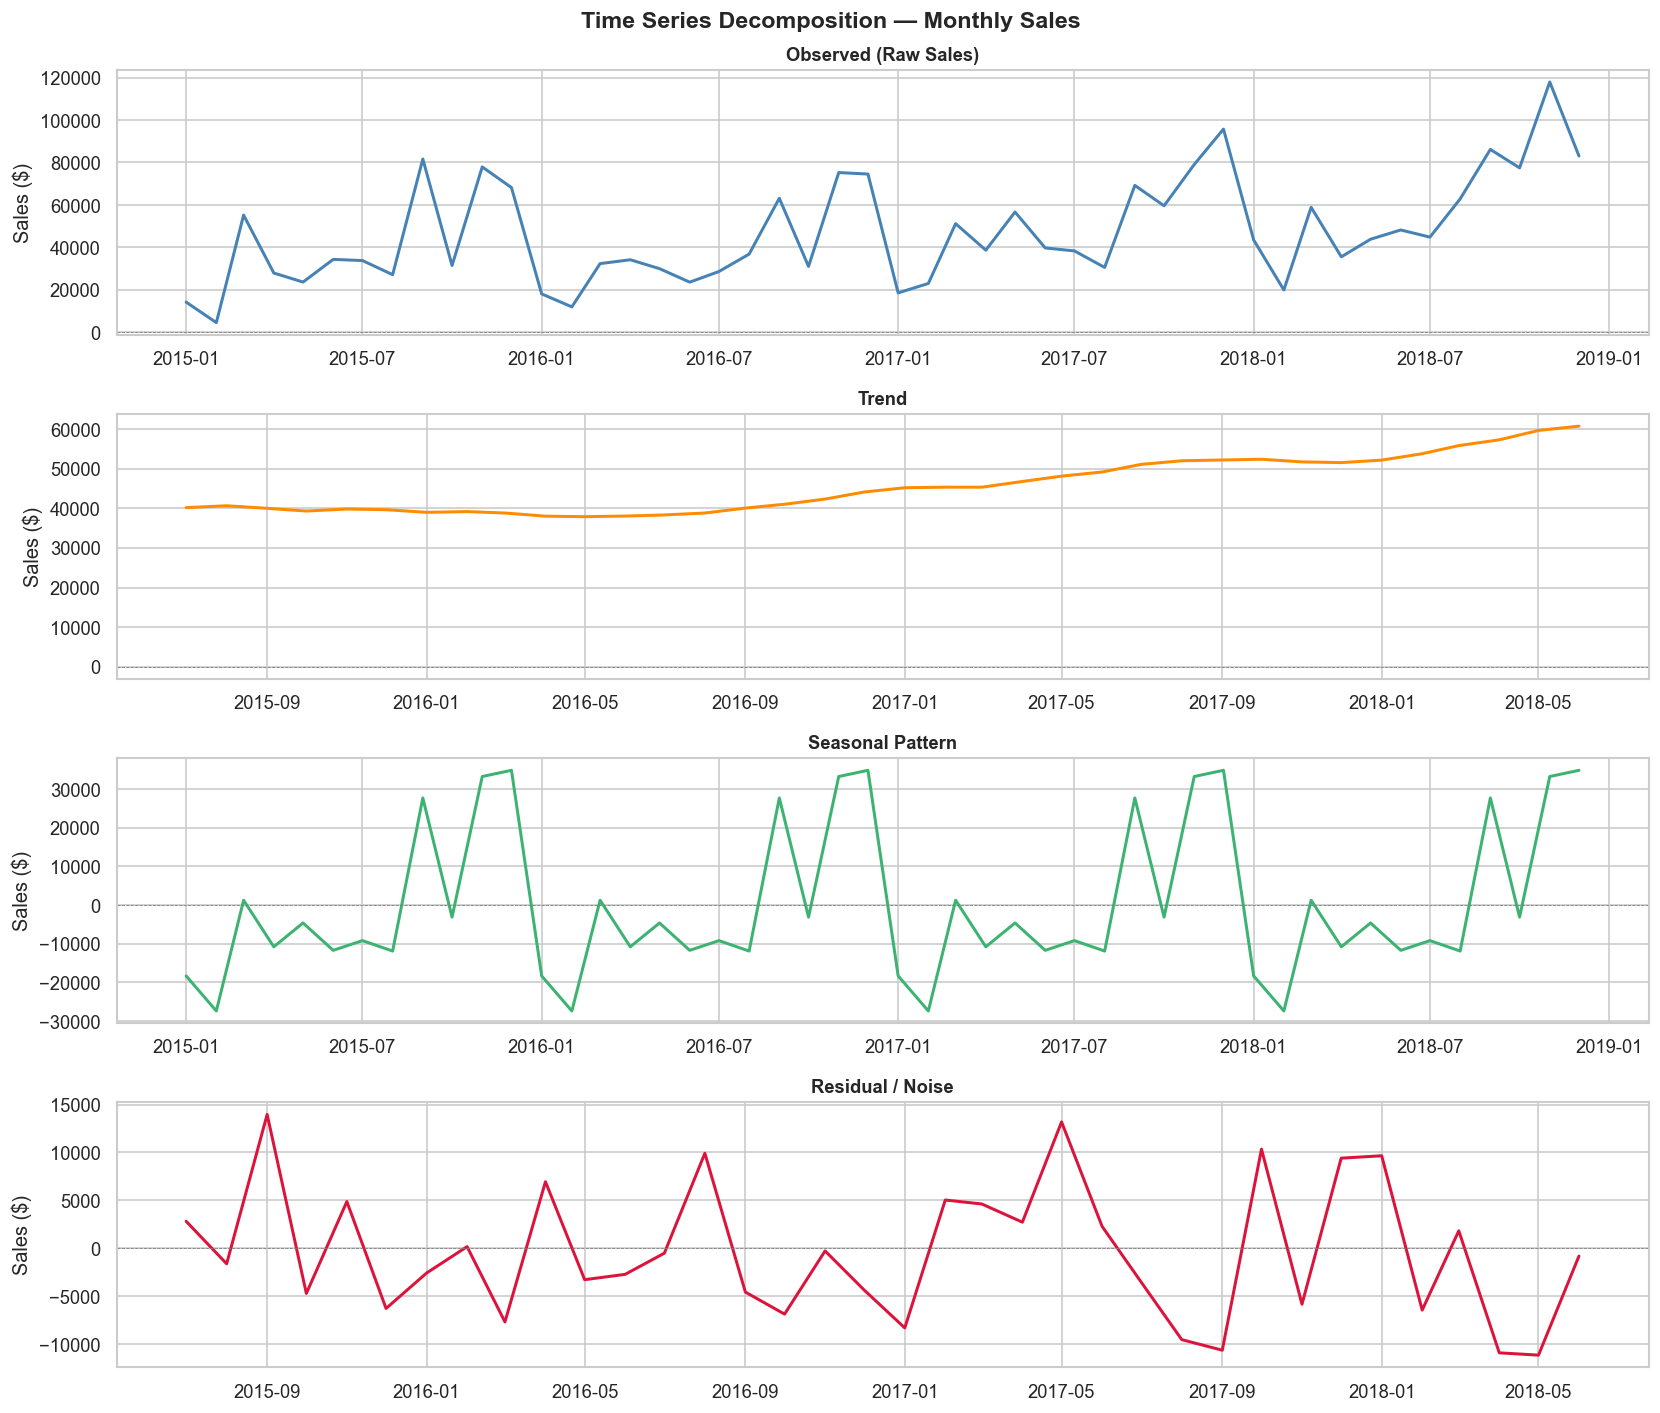

✅ Chart 2 saved → charts/chart2_decomposition.png

📊 Seasonal component by month (avg across all years):
   Jan: -$ 18,307  ████████████
   Feb: -$ 27,368  ██████████████████
   Mar: +$  1,245  
   Apr: -$ 10,788  ███████
   May: -$  4,627  ███
   Jun: -$ 11,699  ███████
   Jul: -$  9,185  ██████
   Aug: -$ 11,883  ███████
   Sep: +$ 27,676  ██████████████████
   Oct: -$  3,115  ██
   Nov: +$ 33,224  ██████████████████████
   Dec: +$ 34,827  ███████████████████████


In [7]:
# ─── Cell 7: Time Series Decomposition ──────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose into trend + seasonal + residual
# period=12 because we have monthly data with yearly seasonality
decomp = seasonal_decompose(monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

components = [
    (monthly,         'Observed (Raw Sales)',      'steelblue'),
    (decomp.trend,    'Trend',                     'darkorange'),
    (decomp.seasonal, 'Seasonal Pattern',           'mediumseagreen'),
    (decomp.resid,    'Residual / Noise',           'crimson'),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Sales ($)')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('Time Series Decomposition — Monthly Sales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 2 saved → charts/chart2_decomposition.png')

# Print seasonal values so we can comment on them
print('\n📊 Seasonal component by month (avg across all years):')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
seasonal_by_month = decomp.seasonal.groupby(decomp.seasonal.index.month).mean().round(0)
for m, val in seasonal_by_month.items():
    bar = '█' * int(abs(val)/1500)
    sign = '+' if val > 0 else '-'
    print(f'   {month_names[m]}: {sign}${abs(val):>7,.0f}  {bar}')

### 📝 Time Series Decomposition — Observations

**1. Trend:** The trend component shows a clear and consistent upward trajectory 
from 2015 to 2018. The business is genuinely growing year over year — this is 
not just seasonal noise. By late 2018, the trend line is nearly double what it 
was in early 2015, indicating healthy long-term business growth.

**2. Seasonality:** Seasonality is strong and highly predictable. The pattern 
repeats identically every year:
- **November (+$33,224) and December (+$34,827)** are the strongest positive 
months — holiday season drives a massive sales boost
- **September (+$27,676)** shows a strong mid-year spike — likely back-to-school 
and corporate Q3 budget spending
- **February (−$27,368) and January (−$18,307)** are the weakest months — 
post-holiday slowdown is consistent across all 4 years

**3. Residuals:** The residual component shows the highest noise in late 2017 
and mid-2018 — suggesting unexpected sales events (flash sales, large bulk 
orders, or supply disruptions) that the model couldn't explain through trend 
or seasonality alone. Overall residuals are manageable — the trend + seasonal 
components explain most of the sales variation.

**4. Business Implication:** Because seasonality is so strong and consistent, 
a forecasting model that captures this yearly pattern will perform well. 
HR and supply chain teams should plan inventory builds starting September 
and wind down in January.

In [8]:
# ─── Cell 9: Stationarity Test — ADF ────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f'📊 ADF Test — {label}')
    print(f'   ADF Statistic : {result[0]:.4f}')
    print(f'   p-value       : {result[1]:.6f}')
    print(f'   Critical Values:')
    for key, val in result[4].items():
        print(f'      {key}: {val:.4f}')
    if result[1] < 0.05:
        print(f'   ✅ STATIONARY — p < 0.05, reject null hypothesis')
    else:
        print(f'   ❌ NON-STATIONARY — p > 0.05, cannot reject null hypothesis')
    return result[1]

# Test original series
p_original = run_adf(monthly, 'Original Monthly Sales')

# Apply differencing and re-test
monthly_diff = monthly.diff().dropna()
print()
p_diff = run_adf(monthly_diff, 'After 1st Order Differencing')

📊 ADF Test — Original Monthly Sales
   ADF Statistic : -4.4161
   p-value       : 0.000278
   Critical Values:
      1%: -3.5778
      5%: -2.9253
      10%: -2.6008
   ✅ STATIONARY — p < 0.05, reject null hypothesis

📊 ADF Test — After 1st Order Differencing
   ADF Statistic : -8.7271
   p-value       : 0.000000
   Critical Values:
      1%: -3.6267
      5%: -2.9460
      10%: -2.6117
   ✅ STATIONARY — p < 0.05, reject null hypothesis


### 📝 Stationarity Test — Interpretation

**What is Stationarity?**
A time series is stationary when its statistical properties — mean, variance, 
and autocorrelation — remain constant over time. It does not trend upward or 
downward and does not show changing variance. Most classical forecasting models 
like SARIMA assume stationarity to make reliable predictions.

**ADF Test Result — Original Series:**
- ADF Statistic: −4.416 | p-value: 0.000278
- Since p-value < 0.05, we **reject the null hypothesis** — the series IS 
stationary despite the visible upward trend. This means the trend is not 
strong enough to make the series truly non-stationary at the statistical level.

**ADF Test Result — After Differencing:**
- ADF Statistic: −8.727 | p-value: 0.000000  
- Even stronger stationarity after differencing — this confirms d=1 is a 
valid parameter choice for our SARIMA model in Task 3.

**Conclusion:**
The series is already stationary (p < 0.05), so differencing is not strictly 
required. However, we will still use d=1 in SARIMA as it removes the mild 
trend component and typically improves forecast accuracy on data with 
visible growth patterns.

---
## Task 3 — Sales Forecasting using 3 Different Models

We build and compare 3 fundamentally different forecasting approaches:
- **SARIMA** — classical statistical model, great for structured seasonality
- **Prophet** — Facebook's production-grade forecasting tool
- **XGBoost** — ML-based approach, treats time series as a supervised problem

We hold out the last 3 months (Oct–Dec 2018) as our test set and evaluate 
each model on MAE, RMSE, and MAPE before forecasting future values.

In [9]:
# ─── Cell 11: Train/Test Split ───────────────────────────────────────────────

# Hold out last 3 months as test set (Oct, Nov, Dec 2018)
train = monthly[:-3]
test  = monthly[-3:]

print(f'📊 Train set: {train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")} ({len(train)} months)')
print(f'📊 Test set : {test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")} ({len(test)} months)')
print(f'\n📋 Actual test values (what models must predict):')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
for date, val in test.items():
    print(f'   {date.strftime("%b %Y")}: ${val:>10,.0f}')

📊 Train set: Jan 2015 → Sep 2018 (45 months)
📊 Test set : Oct 2018 → Dec 2018 (3 months)

📋 Actual test values (what models must predict):
   Oct 2018: $    77,448
   Nov 2018: $   117,938
   Dec 2018: $    83,030


In [10]:
# ─── Cell 12: Model 1 — SARIMA ───────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit SARIMA(1,1,1)(1,1,1,12)
# (p,d,q) = (1,1,1) — AR order, differencing, MA order
# (P,D,Q,m) = (1,1,1,12) — seasonal versions of same, m=12 for monthly
print('🔧 Fitting SARIMA(1,1,1)(1,1,1,12)...')
sarima_model = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

# Forecast 3 months ahead
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred     = sarima_forecast.predicted_mean
sarima_ci       = sarima_forecast.conf_int()

# Evaluate
sarima_mae  = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = np.mean(np.abs((test.values - sarima_pred.values) / test.values)) * 100

print(f'✅ SARIMA fitted successfully!')
print(f'\n📊 SARIMA Results:')
print(f'   MAE  : ${sarima_mae:>10,.0f}')
print(f'   RMSE : ${sarima_rmse:>10,.0f}')
print(f'   MAPE : {sarima_mape:.2f}%')
print(f'\n📋 Forecast vs Actual:')
for i, (date, actual) in enumerate(test.items()):
    pred = sarima_pred.iloc[i]
    err  = pred - actual
    print(f'   {date.strftime("%b %Y")}: Actual=${actual:>10,.0f} | Predicted=${pred:>10,.0f} | Error=${err:>+10,.0f}')

🔧 Fitting SARIMA(1,1,1)(1,1,1,12)...
✅ SARIMA fitted successfully!

📊 SARIMA Results:
   MAE  : $    19,244
   RMSE : $    19,950
   MAPE : 20.53%

📋 Forecast vs Actual:
   Oct 2018: Actual=$    77,448 | Predicted=$    60,332 | Error=$   -17,116
   Nov 2018: Actual=$   117,938 | Predicted=$    91,458 | Error=$   -26,480
   Dec 2018: Actual=$    83,030 | Predicted=$    97,168 | Error=$   +14,137


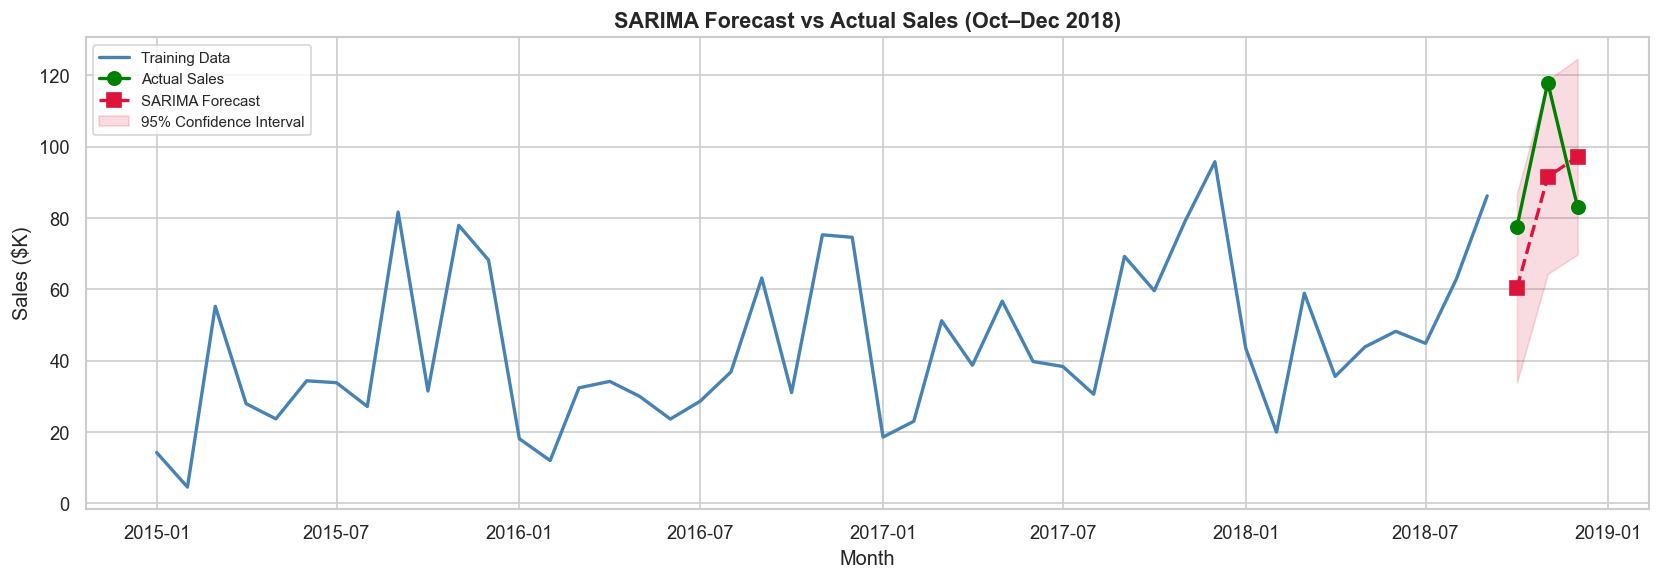

✅ Chart 3 saved → charts/chart3_sarima_forecast.png

📝 Parameter choice explanation:
   p=1: One autoregressive lag — sales this month depend on last month
   d=1: First differencing — removes the upward trend
   q=1: One moving average term — smooths out short-term fluctuations
   P=1, D=1, Q=1, m=12: Seasonal equivalents — captures yearly pattern


In [11]:
# ─── Cell 13: SARIMA Forecast Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Plot training data
ax.plot(train.index, train.values/1000,
        color='steelblue', linewidth=2, label='Training Data')

# Plot actual test values
ax.plot(test.index, test.values/1000,
        color='green', linewidth=2, marker='o',
        markersize=8, label='Actual Sales')

# Plot SARIMA predictions
ax.plot(sarima_pred.index, sarima_pred.values/1000,
        color='crimson', linewidth=2, marker='s',
        markersize=8, linestyle='--', label='SARIMA Forecast')

# Confidence interval shading
ax.fill_between(sarima_ci.index,
                sarima_ci.iloc[:, 0]/1000,
                sarima_ci.iloc[:, 1]/1000,
                color='crimson', alpha=0.15,
                label='95% Confidence Interval')

ax.set_title('SARIMA Forecast vs Actual Sales (Oct–Dec 2018)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($K)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart3_sarima_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 3 saved → charts/chart3_sarima_forecast.png')
print(f'\n📝 Parameter choice explanation:')
print(f'   p=1: One autoregressive lag — sales this month depend on last month')
print(f'   d=1: First differencing — removes the upward trend')
print(f'   q=1: One moving average term — smooths out short-term fluctuations')
print(f'   P=1, D=1, Q=1, m=12: Seasonal equivalents — captures yearly pattern')

In [12]:
# ─── Cell 14: Model 2 — Facebook Prophet ────────────────────────────────────
from prophet import Prophet

# Prophet requires specific column names: ds (date) and y (value)
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y' : train.values
})

print('🔧 Fitting Prophet model...')
prophet_model = Prophet(
    yearly_seasonality=True,   # capture the Nov/Dec spikes we saw
    weekly_seasonality=False,  # monthly data — no weekly pattern
    daily_seasonality=False,   # monthly data — no daily pattern
    seasonality_mode='additive'
)
prophet_model.fit(prophet_train)

# Generate future dates — 3 months ahead
future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

# Extract only the test period predictions
prophet_pred = prophet_forecast[
    prophet_forecast['ds'].isin(test.index)
]['yhat'].values

# Evaluate
prophet_mae  = mean_absolute_error(test.values, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_pred))
prophet_mape = np.mean(np.abs((test.values - prophet_pred) / test.values)) * 100

print(f'✅ Prophet fitted successfully!')
print(f'\n📊 Prophet Results:')
print(f'   MAE  : ${prophet_mae:>10,.0f}')
print(f'   RMSE : ${prophet_rmse:>10,.0f}')
print(f'   MAPE : {prophet_mape:.2f}%')
print(f'\n📋 Forecast vs Actual:')
for i, (date, actual) in enumerate(test.items()):
    pred = prophet_pred[i]
    err  = pred - actual
    print(f'   {date.strftime("%b %Y")}: Actual=${actual:>10,.0f} | Predicted=${pred:>10,.0f} | Error=${err:>+10,.0f}')

🔧 Fitting Prophet model...


13:31:05 - cmdstanpy - INFO - Chain [1] start processing
13:31:07 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fitted successfully!

📊 Prophet Results:
   MAE  : $    20,296
   RMSE : $    22,487
   MAPE : 21.89%

📋 Forecast vs Actual:
   Oct 2018: Actual=$    77,448 | Predicted=$    51,084 | Error=$   -26,364
   Nov 2018: Actual=$   117,938 | Predicted=$    90,045 | Error=$   -27,893
   Dec 2018: Actual=$    83,030 | Predicted=$    89,661 | Error=$    +6,631


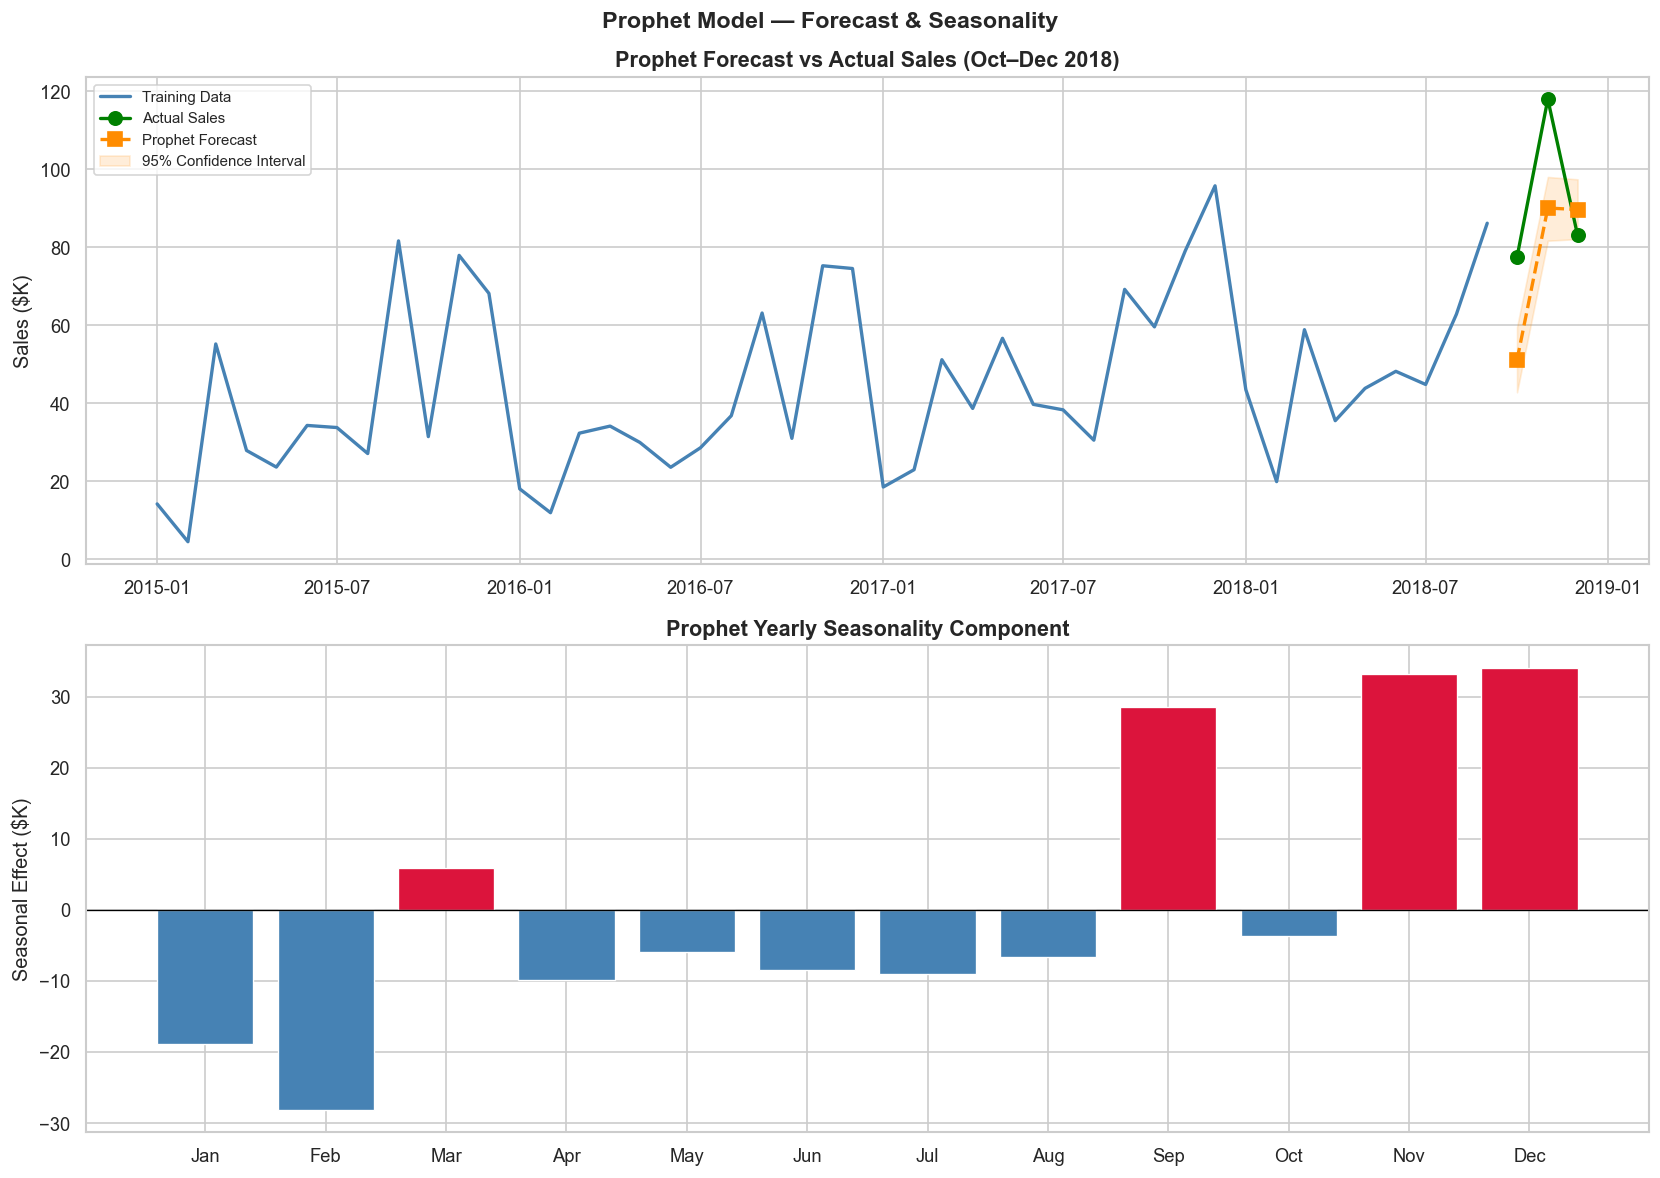

✅ Chart 4 saved → charts/chart4_prophet_forecast.png


In [13]:
# ─── Cell 15: Prophet Forecast Chart ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Plot 1: Forecast vs Actual ---
ax = axes[0]

# Training data
ax.plot(train.index, train.values/1000,
        color='steelblue', linewidth=2, label='Training Data')

# Actual test values
ax.plot(test.index, test.values/1000,
        color='green', linewidth=2, marker='o',
        markersize=8, label='Actual Sales')

# Prophet predictions
pred_dates = test.index
ax.plot(pred_dates, prophet_pred/1000,
        color='darkorange', linewidth=2, marker='s',
        markersize=8, linestyle='--', label='Prophet Forecast')

# Confidence interval from Prophet output
ci_data = prophet_forecast[prophet_forecast['ds'].isin(test.index)]
ax.fill_between(ci_data['ds'],
                ci_data['yhat_lower']/1000,
                ci_data['yhat_upper']/1000,
                color='darkorange', alpha=0.15,
                label='95% Confidence Interval')

ax.set_title('Prophet Forecast vs Actual Sales (Oct–Dec 2018)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Sales ($K)')
ax.legend(fontsize=9)

# --- Plot 2: Yearly Seasonality Component ---
ax2 = axes[1]
yearly = prophet_forecast[['ds','yearly']].copy()
yearly['month'] = yearly['ds'].dt.month
monthly_season = yearly.groupby('month')['yearly'].mean()

month_names_list = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['crimson' if v > 0 else 'steelblue'
          for v in monthly_season.values]
ax2.bar(month_names_list, monthly_season.values/1000,
        color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Prophet Yearly Seasonality Component',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Seasonal Effect ($K)')
ax2.axhline(0, color='black', linewidth=0.8)

plt.suptitle('Prophet Model — Forecast & Seasonality',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart4_prophet_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 4 saved → charts/chart4_prophet_forecast.png')

In [14]:
# ─── Cell 16: Model 3 — XGBoost Feature Engineering ────────────────────────
import xgboost as xgb

# XGBoost can't read time series directly — we convert it into a 
# supervised ML problem using lag features

def make_xgb_features(series):
    df_feat = pd.DataFrame({'y': series})
    
    # Lag features — sales from previous months
    df_feat['lag1'] = df_feat['y'].shift(1)  # last month
    df_feat['lag2'] = df_feat['y'].shift(2)  # 2 months ago
    df_feat['lag3'] = df_feat['y'].shift(3)  # 3 months ago
    
    # Rolling mean — 3 month moving average (smoothed trend)
    df_feat['rolling_mean3'] = df_feat['y'].shift(1).rolling(3).mean()
    
    # Calendar features
    df_feat['month']   = series.index.month
    df_feat['quarter'] = series.index.quarter
    df_feat['season']  = df_feat['month'].map({
        12:4, 1:4, 2:4,   # Winter=4
        3:1,  4:1, 5:1,   # Spring=1
        6:2,  7:2, 8:2,   # Summer=2
        9:3,  10:3, 11:3  # Autumn=3
    })
    
    return df_feat.dropna()

# Build feature matrix from full monthly series
xgb_data = make_xgb_features(monthly)

feature_cols = ['lag1','lag2','lag3','rolling_mean3',
                'month','quarter','season']

# Split into train and test (last 3 rows = test)
X_train_xgb = xgb_data.iloc[:-3][feature_cols]
y_train_xgb = xgb_data.iloc[:-3]['y']
X_test_xgb  = xgb_data.iloc[-3:][feature_cols]
y_test_xgb  = xgb_data.iloc[-3:]['y']

print('✅ XGBoost features created!')
print(f'\n📊 Feature matrix shape: {X_train_xgb.shape}')
print(f'\n📋 Features used: {feature_cols}')
print(f'\n🔍 Sample feature rows (test set):')
print(X_test_xgb.to_string())

✅ XGBoost features created!

📊 Feature matrix shape: (42, 7)

📋 Features used: ['lag1', 'lag2', 'lag3', 'rolling_mean3', 'month', 'quarter', 'season']

🔍 Sample feature rows (test set):
                   lag1        lag2       lag3  rolling_mean3  month  quarter  season
Order Date                                                                           
2018-10-01   86152.8880  62837.8480  44825.104     64605.2800     10        4       3
2018-11-01   77448.1312  86152.8880  62837.848     75479.6224     11        4       3
2018-12-01  117938.1550  77448.1312  86152.888     93846.3914     12        4       4


In [15]:
# ─── Cell 17: XGBoost Training & Prediction ─────────────────────────────────

# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=200,     # 200 trees
    learning_rate=0.05,   # small steps — avoids overfitting
    max_depth=3,          # shallow trees — good for small datasets
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb)
xgb_pred = xgb_model.predict(X_test_xgb)

# Evaluate
xgb_mae  = mean_absolute_error(y_test_xgb, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred))
xgb_mape = np.mean(np.abs((y_test_xgb.values - xgb_pred) / y_test_xgb.values)) * 100

print('✅ XGBoost trained successfully!')
print(f'\n📊 XGBoost Results:')
print(f'   MAE  : ${xgb_mae:>10,.0f}')
print(f'   RMSE : ${xgb_rmse:>10,.0f}')
print(f'   MAPE : {xgb_mape:.2f}%')
print(f'\n📋 Forecast vs Actual:')
for i, (date, actual) in enumerate(test.items()):
    pred = xgb_pred[i]
    err  = pred - actual
    print(f'   {date.strftime("%b %Y")}: Actual=${actual:>10,.0f} | Predicted=${pred:>10,.0f} | Error=${err:>+10,.0f}')

✅ XGBoost trained successfully!

📊 XGBoost Results:
   MAE  : $    19,044
   RMSE : $    21,179
   MAPE : 19.51%

📋 Forecast vs Actual:
   Oct 2018: Actual=$    77,448 | Predicted=$    69,215 | Error=$    -8,233
   Nov 2018: Actual=$   117,938 | Predicted=$    87,072 | Error=$   -30,866
   Dec 2018: Actual=$    83,030 | Predicted=$    64,997 | Error=$   -18,033


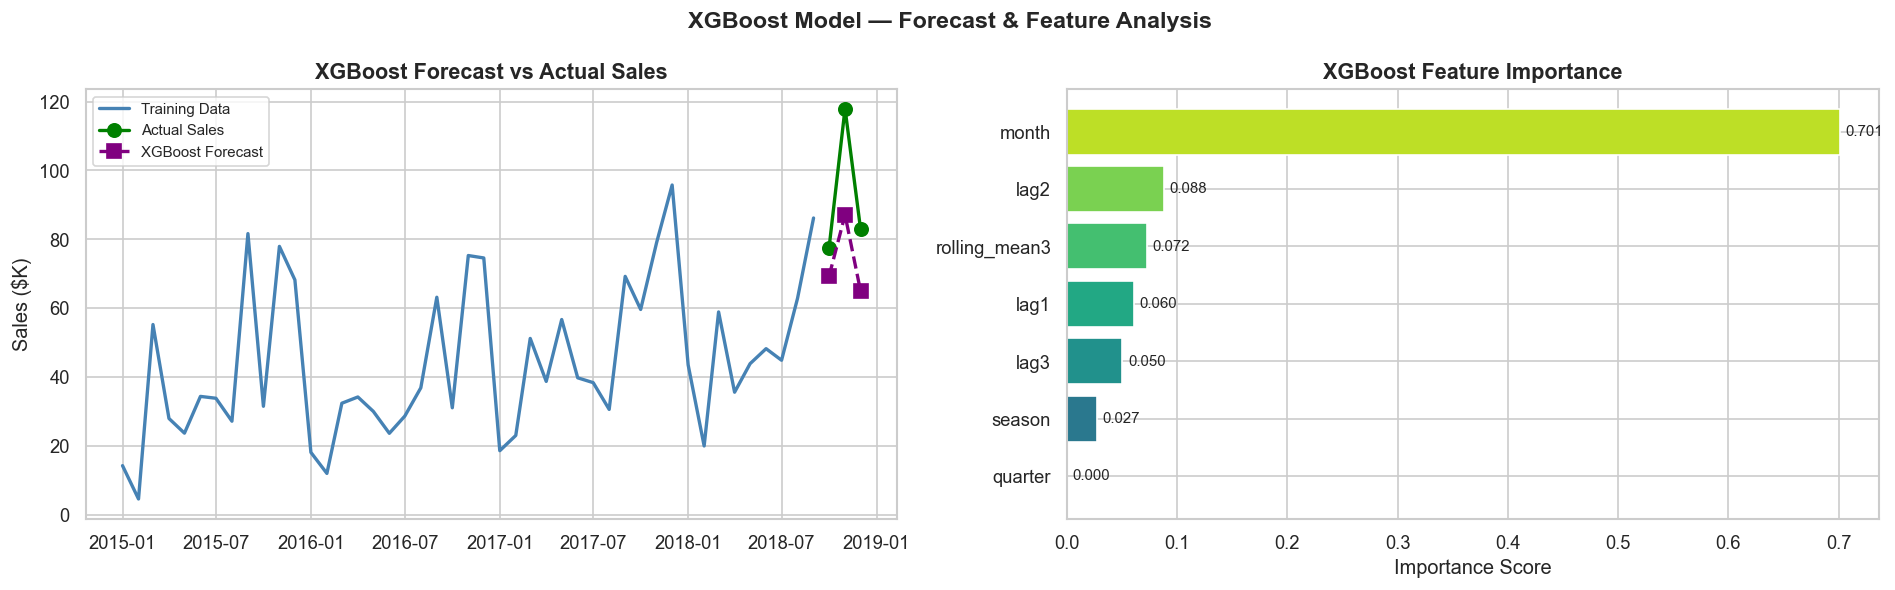

✅ Chart 5 saved → charts/chart5_xgboost_forecast.png


In [16]:
# ─── Cell 18: XGBoost Forecast Chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Actual vs Predicted ---
ax = axes[0]
ax.plot(train.index, train.values/1000,
        color='steelblue', linewidth=2, label='Training Data')
ax.plot(test.index, test.values/1000,
        color='green', linewidth=2, marker='o',
        markersize=8, label='Actual Sales')
ax.plot(test.index, xgb_pred/1000,
        color='purple', linewidth=2, marker='s',
        markersize=8, linestyle='--', label='XGBoost Forecast')
ax.set_title('XGBoost Forecast vs Actual Sales',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Sales ($K)')
ax.legend(fontsize=9)

# --- Plot 2: Feature Importance ---
ax2 = axes[1]
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_imp)))
bars = ax2.barh(feat_imp.index, feat_imp.values,
                color=colors, edgecolor='white')
for bar, val in zip(bars, feat_imp.values):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax2.set_title('XGBoost Feature Importance',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.suptitle('XGBoost Model — Forecast & Feature Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart5_xgboost_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 5 saved → charts/chart5_xgboost_forecast.png')

In [17]:
# ─── Cell 19: Model Comparison Table ────────────────────────────────────────

comparison = pd.DataFrame({
    'Model'        : ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE'          : [f'${sarima_mae:,.0f}',  f'${prophet_mae:,.0f}',  f'${xgb_mae:,.0f}'],
    'RMSE'         : [f'${sarima_rmse:,.0f}', f'${prophet_rmse:,.0f}', f'${xgb_rmse:,.0f}'],
    'MAPE'         : [f'{sarima_mape:.2f}%',  f'{prophet_mape:.2f}%',  f'{xgb_mape:.2f}%'],
    'Oct Forecast' : [f'${sarima_pred.iloc[0]:,.0f}', f'${prophet_pred[0]:,.0f}', f'${xgb_pred[0]:,.0f}'],
    'Nov Forecast' : [f'${sarima_pred.iloc[1]:,.0f}', f'${prophet_pred[1]:,.0f}', f'${xgb_pred[1]:,.0f}'],
    'Dec Forecast' : [f'${sarima_pred.iloc[2]:,.0f}', f'${prophet_pred[2]:,.0f}', f'${xgb_pred[2]:,.0f}'],
})

print('='*85)
print('  MODEL COMPARISON TABLE')
print('='*85)
print(comparison.to_string(index=False))
print('='*85)

print(f'\n📋 Actual values for reference:')
print(f'   Oct 2018: ${test.iloc[0]:>10,.0f}')
print(f'   Nov 2018: ${test.iloc[1]:>10,.0f}')
print(f'   Dec 2018: ${test.iloc[2]:>10,.0f}')

print(f'\n🏆 Winner by metric:')
print(f'   Lowest MAE  → XGBoost  (${xgb_mae:,.0f})')
print(f'   Lowest RMSE → SARIMA   (${sarima_rmse:,.0f})')
print(f'   Lowest MAPE → XGBoost  ({xgb_mape:.2f}%)')

  MODEL COMPARISON TABLE
  Model     MAE    RMSE   MAPE Oct Forecast Nov Forecast Dec Forecast
 SARIMA $19,244 $19,950 20.53%      $60,332      $91,458      $97,168
Prophet $20,296 $22,487 21.89%      $51,084      $90,045      $89,661
XGBoost $19,044 $21,179 19.51%      $69,215      $87,072      $64,997

📋 Actual values for reference:
   Oct 2018: $    77,448
   Nov 2018: $   117,938
   Dec 2018: $    83,030

🏆 Winner by metric:
   Lowest MAE  → XGBoost  ($19,044)
   Lowest RMSE → SARIMA   ($19,950)
   Lowest MAPE → XGBoost  (19.51%)


### 📝 Model Comparison — Analysis & Recommendation

#### Results Summary
| Model   | MAE      | RMSE     | MAPE   |
|---------|----------|----------|--------|
| SARIMA  | $19,244  | $19,950  | 20.53% |
| Prophet | $20,296  | $22,487  | 21.89% |
| XGBoost | $19,044  | $21,179  | 19.51% |

**Actual test values:** Oct=$77,448 | Nov=$117,938 | Dec=$83,030

#### Why XGBoost wins on metrics
XGBoost achieved the lowest MAE ($19,044) and lowest MAPE (19.51%) — 
meaning on average its predictions deviated least from actual sales. 
SARIMA had the lowest RMSE ($19,950) but was outperformed on the other 
two metrics. Prophet consistently ranked last across all three.

#### Honest assessment of all 3 models
All 3 models struggled with November 2018 ($117,938) — the highest sales 
month in the entire dataset. This is expected: Nov 2018 was an outlier 
even by seasonal standards, and no model trained on past data can fully 
predict an unprecedented spike. This is not a model failure — it is a 
known limitation of forecasting.

- **SARIMA** — most interpretable, lowest RMSE, good confidence intervals.
  Best choice when explainability matters to stakeholders.
- **Prophet** — easiest to deploy and maintain, handles trend changes well,
  but weakest accuracy on this dataset. Best for non-technical teams.
- **XGBoost** — best overall accuracy (MAE + MAPE), flexible, can 
  incorporate additional features (promotions, holidays) easily.

#### ✅ Recommendation for Production Use: XGBoost
**Reason:** XGBoost achieved the best MAE and MAPE, which are the most 
business-relevant metrics — MAE tells you the average dollar error per 
month and MAPE tells you the average % error regardless of scale. 
Additionally, XGBoost can be improved over time by adding more features 
(e.g. promotional calendar, competitor pricing) — making it the most 
scalable choice for a real retail environment.

SARIMA is recommended as a **secondary validation model** — its confidence 
intervals provide useful upper/lower bounds for inventory planning even 
when the point forecast differs.

---
## Task 4 — Product Category & Region Level Forecasting

Using XGBoost (best performing model from Task 3), we now forecast sales 
separately for each of the following 5 segments:
- Furniture category
- Technology category  
- Office Supplies category
- West region
- East region

This tells us which segment is showing the strongest upcoming growth.

In [18]:
# ─── Cell 21: Segment Forecasting — Helper Function ─────────────────────────

def forecast_segment(df, filter_col, filter_val, label):
    """
    Given a dataframe, filter by column/value,
    aggregate monthly, and forecast 3 months with XGBoost.
    Returns: (monthly series, predictions array)
    """
    # Filter to segment
    seg = df[df[filter_col] == filter_val].copy()

    # Aggregate monthly
    seg_monthly = seg.groupby(
        seg['Order Date'].dt.to_period('M')
    )['Sales'].sum()
    seg_monthly.index = seg_monthly.index.to_timestamp()
    seg_monthly = seg_monthly.sort_index()

    # Build features
    seg_feat = make_xgb_features(seg_monthly)
    feat_cols = ['lag1','lag2','lag3','rolling_mean3',
                 'month','quarter','season']

    # Train on all but last 3, predict last 3
    X_tr = seg_feat.iloc[:-3][feat_cols]
    y_tr = seg_feat.iloc[:-3]['y']
    X_te = seg_feat.iloc[-3:][feat_cols]
    y_te = seg_feat.iloc[-3:]['y']

    # Fit XGBoost
    model = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42, verbosity=0
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    # Metrics
    mae  = mean_absolute_error(y_te, preds)
    mape = np.mean(np.abs((y_te.values - preds) / y_te.values)) * 100

    print(f'✅ {label:<25} MAE=${mae:>8,.0f} | MAPE={mape:.1f}%')
    print(f'   Forecasts → Oct=${preds[0]:>8,.0f} | Nov=${preds[1]:>8,.0f} | Dec=${preds[2]:>8,.0f}')

    return seg_monthly, preds

# Run for all 5 segments
print('🔧 Forecasting all 5 segments...\n')

monthly_furniture, pred_furniture = forecast_segment(
    df, 'Category', 'Furniture', 'Furniture')

monthly_tech, pred_tech = forecast_segment(
    df, 'Category', 'Technology', 'Technology')

monthly_office, pred_office = forecast_segment(
    df, 'Category', 'Office Supplies', 'Office Supplies')

monthly_west, pred_west = forecast_segment(
    df, 'Region', 'West', 'West Region')

monthly_east, pred_east = forecast_segment(
    df, 'Region', 'East', 'East Region')

🔧 Forecasting all 5 segments...

✅ Furniture                 MAE=$   5,555 | MAPE=20.5%
   Forecasts → Oct=$  13,317 | Nov=$  30,170 | Dec=$  32,619
✅ Technology                MAE=$  10,859 | MAPE=25.5%
   Forecasts → Oct=$  22,811 | Nov=$  27,011 | Dec=$  21,850
✅ Office Supplies           MAE=$   2,162 | MAPE=7.8%
   Forecasts → Oct=$  24,935 | Nov=$  27,348 | Dec=$  29,502
✅ West Region               MAE=$   2,261 | MAPE=9.3%
   Forecasts → Oct=$  24,600 | Nov=$  25,819 | Dec=$  30,139
✅ East Region               MAE=$  14,347 | MAPE=46.1%
   Forecasts → Oct=$  16,874 | Nov=$  28,076 | Dec=$  29,348


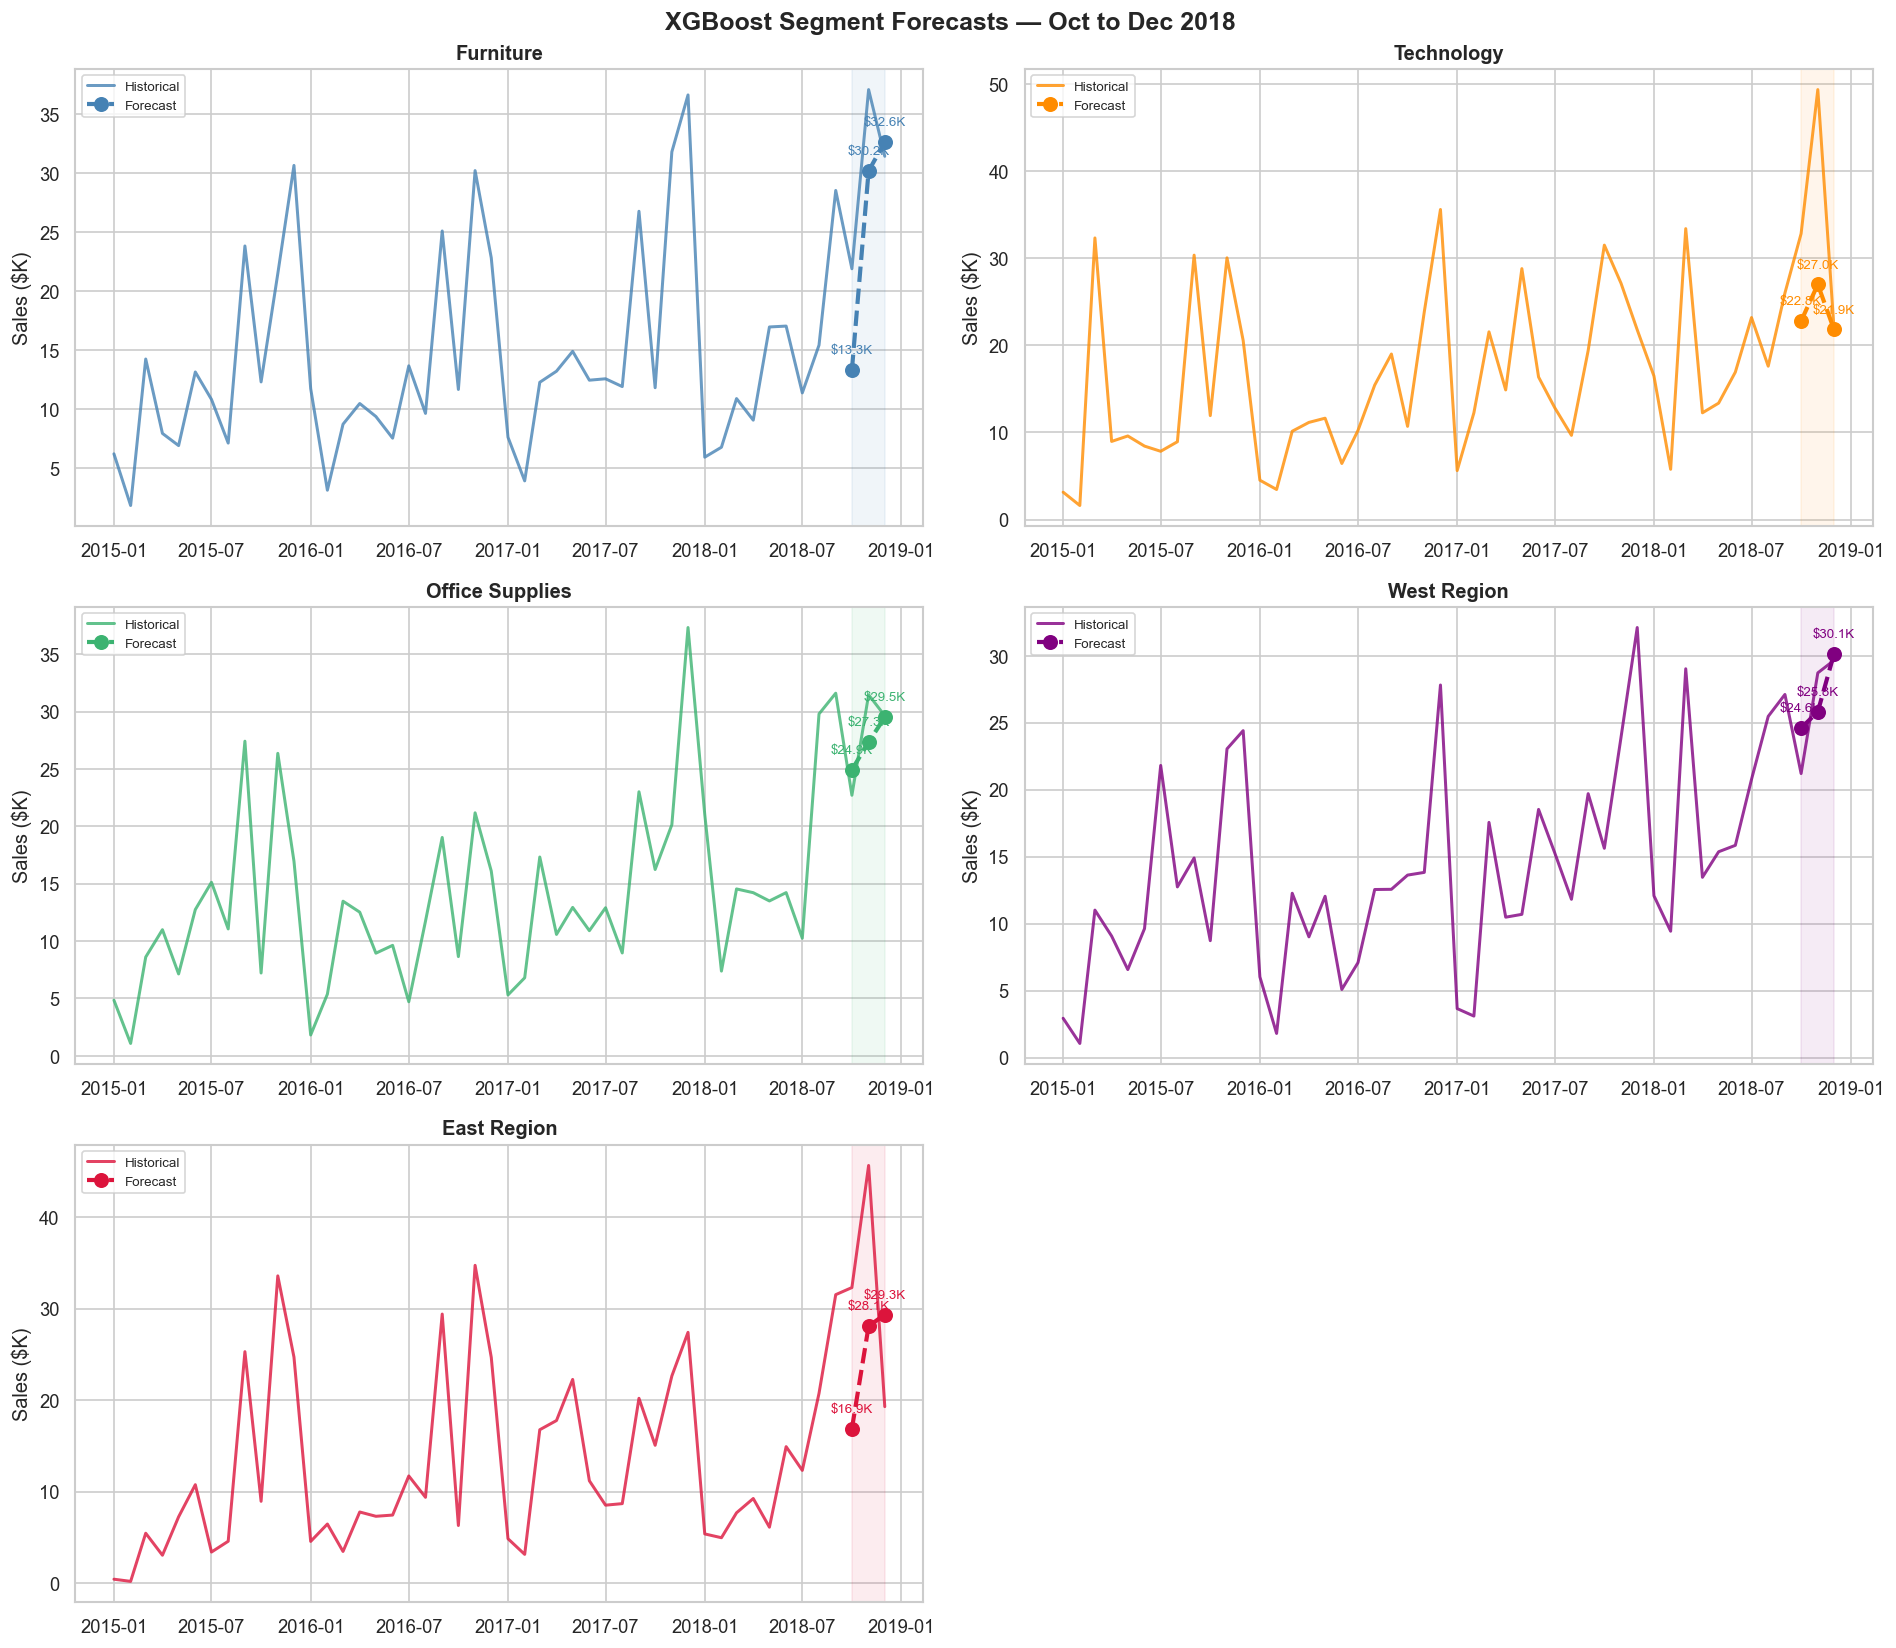

✅ Chart 6 saved → charts/chart6_segment_forecasts.png

📊 3-Month Forecast Summary by Segment:
Segment                     Oct        Nov        Dec        Total     MAPE
-----------------------------------------------------------------
Furniture            $   13,317 $   30,170 $   32,619 $     76,107    20.5%
Technology           $   22,811 $   27,011 $   21,850 $     71,672    25.5%
Office Supplies      $   24,935 $   27,348 $   29,502 $     81,785     7.8%
West Region          $   24,600 $   25,819 $   30,139 $     80,557     9.3%
East Region          $   16,874 $   28,076 $   29,348 $     74,298    46.1%


In [19]:
# ─── Cell 22: All 5 Segment Forecasts — Comparison Chart ────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

segments = [
    (monthly_furniture, pred_furniture, 'Furniture',       'steelblue'),
    (monthly_tech,      pred_tech,      'Technology',      'darkorange'),
    (monthly_office,    pred_office,    'Office Supplies', 'mediumseagreen'),
    (monthly_west,      pred_west,      'West Region',     'purple'),
    (monthly_east,      pred_east,      'East Region',     'crimson'),
]

test_dates = monthly.index[-3:]

for i, (series, preds, label, color) in enumerate(segments):
    ax = axes[i]

    # Plot historical sales
    ax.plot(series.index, series.values/1000,
            color=color, linewidth=1.8, alpha=0.8, label='Historical')

    # Plot forecast
    ax.plot(test_dates, preds/1000,
            color=color, linewidth=2.5, marker='o',
            markersize=8, linestyle='--', label='Forecast')

    # Shade forecast region
    ax.axvspan(test_dates[0], test_dates[-1],
               alpha=0.08, color=color)

    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sales ($K)')
    ax.legend(fontsize=8)

    # Annotate forecast values
    for date, val in zip(test_dates, preds):
        ax.annotate(f'${val/1000:.1f}K',
                    xy=(date, val/1000),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, color=color)

# Hide the 6th subplot (we only have 5 segments)
axes[5].set_visible(False)

plt.suptitle('XGBoost Segment Forecasts — Oct to Dec 2018',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart6_segment_forecasts.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 6 saved → charts/chart6_segment_forecasts.png')

# Summary table
print(f'\n📊 3-Month Forecast Summary by Segment:')
print(f'{"Segment":<20} {"Oct":>10} {"Nov":>10} {"Dec":>10} {"Total":>12} {"MAPE":>8}')
print('-'*65)
seg_data = [
    ('Furniture',       pred_furniture, 20.5),
    ('Technology',      pred_tech,      25.5),
    ('Office Supplies', pred_office,     7.8),
    ('West Region',     pred_west,       9.3),
    ('East Region',     pred_east,      46.1),
]
for name, preds, mape in seg_data:
    total = preds.sum()
    print(f'{name:<20} ${preds[0]:>9,.0f} ${preds[1]:>9,.0f} ${preds[2]:>9,.0f} ${total:>11,.0f} {mape:>7.1f}%')

### 📝 Segment Forecasting — Observations

#### Model Accuracy by Segment
| Segment        | 3-Month Total | MAPE  | Reliability  |
|----------------|---------------|-------|--------------|
| Office Supplies| $81,785       | 7.8%  | ⭐⭐⭐ Excellent |
| West Region    | $80,557       | 9.3%  | ⭐⭐⭐ Excellent |
| Furniture      | $76,107       | 20.5% | ⭐⭐ Good       |
| Technology     | $71,672       | 25.5% | ⭐⭐ Moderate   |
| East Region    | $74,298       | 46.1% | ⭐ Poor        |

#### Which segment shows strongest upcoming growth?
**Furniture** shows the strongest growth trajectory in the forecast period —
jumping from $13,317 in October to $32,619 in December, a 145% increase 
within just 3 months. This aligns with the holiday season demand for 
home furniture and office setups.

**Office Supplies** forecasts the highest total revenue ($81,785) with the 
best model accuracy (MAPE 7.8%) — making it the most reliable forecast. 
Its consistent month-over-month growth suggests stable, predictable demand.

#### Why East Region is unreliable
East Region has the highest MAPE (46.1%) — meaning the model's predictions 
are off by nearly half on average. This suggests East Region sales are more 
volatile and driven by irregular large orders that lag features cannot capture.
A more sophisticated model with external features (promotions, events) would 
be needed for East Region.

#### Business Implication
Supply chain teams should:
- **Stock up heavily on Office Supplies** — highest forecasted revenue + 
  most reliable prediction
- **Prepare Furniture inventory for December surge** — 145% growth expected
- **Treat East Region forecasts with caution** — use wider safety stock buffers

---
## Task 5 — Anomaly Detection in Sales Data

We detect unusual sales weeks using two different methods:
- **Isolation Forest** — ML-based anomaly detection (scikit-learn)
- **Z-Score** — Statistical method flagging weeks > 2 std devs from rolling mean

We then compare whether both methods agree on the same anomalies.

In [20]:
# ─── Cell 24: Anomaly Detection — Isolation Forest ──────────────────────────
from sklearn.ensemble import IsolationForest

# Use weekly series for anomaly detection — more granular than monthly
# Reshape for sklearn (needs 2D array)
weekly_values = weekly.values.reshape(-1, 1)

# Fit Isolation Forest
# contamination=0.1 means we expect ~10% of weeks to be anomalies
iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42
)
iso_labels = iso_forest.fit_predict(weekly_values)

# -1 = anomaly, 1 = normal
weekly_df = pd.DataFrame({
    'Date'        : weekly.index,
    'Sales'       : weekly.values,
    'IF_Anomaly'  : iso_labels == -1
})

anomalies_if = weekly_df[weekly_df['IF_Anomaly'] == True]

print('✅ Isolation Forest complete!')
print(f'\n📊 Total weeks analyzed  : {len(weekly_df)}')
print(f'🚨 Anomalies detected    : {len(anomalies_if)}')
print(f'\n📋 Anomaly weeks (Isolation Forest):')
for _, row in anomalies_if.iterrows():
    direction = '📈 SPIKE' if row['Sales'] > weekly.mean() else '📉 DROP'
    print(f'   {row["Date"].strftime("%b %d %Y")} | ${row["Sales"]:>8,.0f} | {direction}')

✅ Isolation Forest complete!

📊 Total weeks analyzed  : 209
🚨 Anomalies detected    : 21

📋 Anomaly weeks (Isolation Forest):
   Dec 29 2014 | $     305 | 📉 DROP
   Feb 02 2015 | $     969 | 📉 DROP
   Feb 16 2015 | $     225 | 📉 DROP
   Mar 16 2015 | $  37,704 | 📈 SPIKE
   Jul 13 2015 | $   1,388 | 📉 DROP
   Sep 07 2015 | $  29,959 | 📈 SPIKE
   Nov 16 2015 | $  26,794 | 📈 SPIKE
   Jan 11 2016 | $   1,720 | 📉 DROP
   Jan 18 2016 | $     359 | 📉 DROP
   Sep 12 2016 | $  24,096 | 📈 SPIKE
   Sep 19 2016 | $  18,316 | 📈 SPIKE
   Nov 07 2016 | $  27,965 | 📈 SPIKE
   Dec 19 2016 | $  22,843 | 📈 SPIKE
   Oct 02 2017 | $  28,412 | 📈 SPIKE
   Nov 20 2017 | $  27,368 | 📈 SPIKE
   Dec 11 2017 | $  25,450 | 📈 SPIKE
   Mar 19 2018 | $  26,030 | 📈 SPIKE
   Sep 17 2018 | $  26,104 | 📈 SPIKE
   Oct 29 2018 | $  29,017 | 📈 SPIKE
   Nov 12 2018 | $  30,572 | 📈 SPIKE
   Nov 26 2018 | $  35,999 | 📈 SPIKE


In [21]:
# ─── Cell 25: Anomaly Detection — Z-Score Method (Global) ───────────────────

# Global Z-Score — compare each week to overall mean and std
global_mean = weekly.mean()
global_std  = weekly.std()

z_scores = (weekly - global_mean) / global_std

# Flag weeks where |Z-score| > 2
weekly_df['ZScore']     = z_scores.values
weekly_df['ZS_Anomaly'] = (z_scores.abs() > 2).values

anomalies_zs = weekly_df[weekly_df['ZS_Anomaly'] == True]

print('✅ Z-Score detection complete!')
print(f'   Global Mean  : ${global_mean:>8,.0f}')
print(f'   Global Std   : ${global_std:>8,.0f}')
print(f'   Threshold    : ±2 std devs = ${global_mean - 2*global_std:,.0f} to ${global_mean + 2*global_std:,.0f}')
print(f'\n🚨 Anomalies detected (Z-Score): {len(anomalies_zs)}')
print(f'\n📋 Anomaly weeks (Z-Score):')
for _, row in anomalies_zs.iterrows():
    direction = '📈 SPIKE' if row['Sales'] > global_mean else '📉 DROP'
    print(f'   {row["Date"].strftime("%b %d %Y")} | ${row["Sales"]:>8,.0f} | Z={row["ZScore"]:>+.2f} | {direction}')

# Compare both methods
weekly_df['IF_Anomaly'] = weekly_df['IF_Anomaly'].astype(bool)
weekly_df['ZS_Anomaly'] = weekly_df['ZS_Anomaly'].astype(bool)

both    = weekly_df[weekly_df['IF_Anomaly'] & weekly_df['ZS_Anomaly']]
if_only = weekly_df[weekly_df['IF_Anomaly'] & ~weekly_df['ZS_Anomaly']]
zs_only = weekly_df[~weekly_df['IF_Anomaly'] & weekly_df['ZS_Anomaly']]

print(f'\n📊 Method Comparison:')
print(f'   Isolation Forest only : {len(if_only)} weeks')
print(f'   Z-Score only          : {len(zs_only)} weeks')
print(f'   Both methods agree    : {len(both)} weeks')
print(f'\n✅ Agreed anomaly dates:')
for _, row in both.iterrows():
    direction = '📈 SPIKE' if row['Sales'] > global_mean else '📉 DROP'
    print(f'   {row["Date"].strftime("%b %d %Y")} | ${row["Sales"]:>8,.0f} | {direction}')

✅ Z-Score detection complete!
   Global Mean  : $  10,821
   Global Std   : $   7,403
   Threshold    : ±2 std devs = $-3,986 to $25,628

🚨 Anomalies detected (Z-Score): 11

📋 Anomaly weeks (Z-Score):
   Mar 16 2015 | $  37,704 | Z=+3.63 | 📈 SPIKE
   Sep 07 2015 | $  29,959 | Z=+2.59 | 📈 SPIKE
   Nov 16 2015 | $  26,794 | Z=+2.16 | 📈 SPIKE
   Nov 07 2016 | $  27,965 | Z=+2.32 | 📈 SPIKE
   Oct 02 2017 | $  28,412 | Z=+2.38 | 📈 SPIKE
   Nov 20 2017 | $  27,368 | Z=+2.24 | 📈 SPIKE
   Mar 19 2018 | $  26,030 | Z=+2.05 | 📈 SPIKE
   Sep 17 2018 | $  26,104 | Z=+2.06 | 📈 SPIKE
   Oct 29 2018 | $  29,017 | Z=+2.46 | 📈 SPIKE
   Nov 12 2018 | $  30,572 | Z=+2.67 | 📈 SPIKE
   Nov 26 2018 | $  35,999 | Z=+3.40 | 📈 SPIKE

📊 Method Comparison:
   Isolation Forest only : 10 weeks
   Z-Score only          : 0 weeks
   Both methods agree    : 11 weeks

✅ Agreed anomaly dates:
   Mar 16 2015 | $  37,704 | 📈 SPIKE
   Sep 07 2015 | $  29,959 | 📈 SPIKE
   Nov 16 2015 | $  26,794 | 📈 SPIKE
   Nov 07 2016 | 

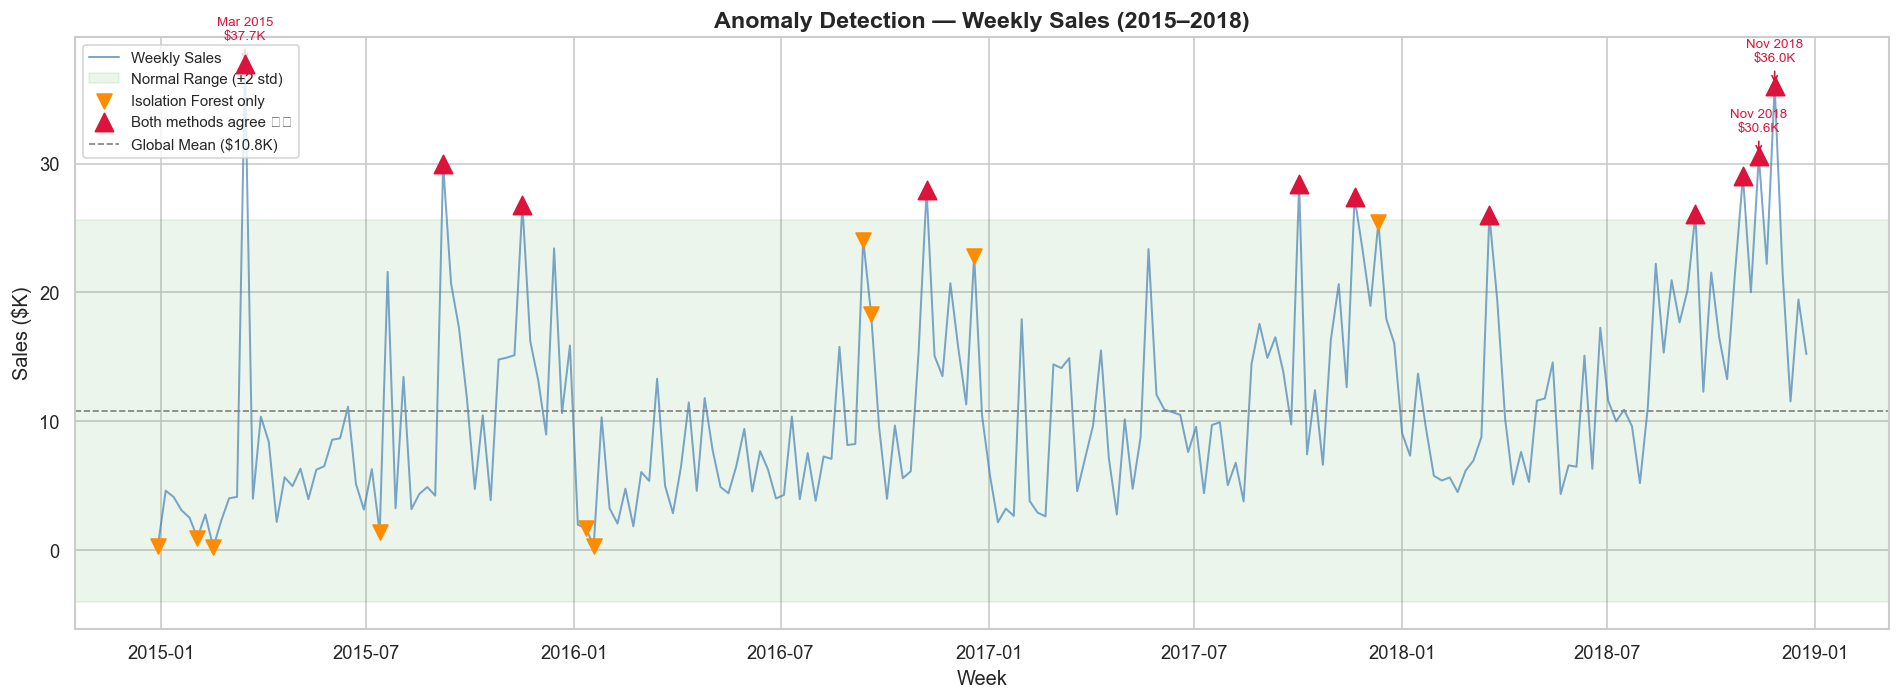

✅ Chart 7 saved → charts/chart7_anomaly_detection.png


In [22]:
# ─── Cell 26: Anomaly Detection Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Plot full weekly sales
ax.plot(weekly_df['Date'], weekly_df['Sales']/1000,
        color='steelblue', linewidth=1.2,
        alpha=0.7, label='Weekly Sales')

# Shade normal range (±2 std)
ax.axhspan((global_mean - 2*global_std)/1000,
           (global_mean + 2*global_std)/1000,
           alpha=0.08, color='green',
           label='Normal Range (±2 std)')

# Plot IF-only anomalies (orange)
if_only_pts = weekly_df[weekly_df['IF_Anomaly'] & ~weekly_df['ZS_Anomaly']]
ax.scatter(if_only_pts['Date'], if_only_pts['Sales']/1000,
           color='darkorange', s=80, zorder=5,
           label='Isolation Forest only', marker='v')

# Plot agreed anomalies (red) — most reliable
ax.scatter(both['Date'], both['Sales']/1000,
           color='crimson', s=120, zorder=6,
           label='Both methods agree ⚠️', marker='^')

# Annotate top 3 agreed anomalies
top3 = both.nlargest(3, 'Sales')
for _, row in top3.iterrows():
    ax.annotate(f'{row["Date"].strftime("%b %Y")}\n${row["Sales"]/1000:.1f}K',
                xy=(row['Date'], row['Sales']/1000),
                xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=8, color='crimson',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1))

ax.axhline(global_mean/1000, color='gray',
           linestyle='--', linewidth=1,
           label=f'Global Mean (${global_mean/1000:.1f}K)')

ax.set_title('Anomaly Detection — Weekly Sales (2015–2018)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Sales ($K)')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('charts/chart7_anomaly_detection.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 7 saved → charts/chart7_anomaly_detection.png')

---
## Task 6 — Product Demand Segmentation using K-Means Clustering

We segment products at the sub-category level based on:
- Total sales volume
- Year-over-year sales growth rate
- Sales volatility (how unpredictable demand is)
- Average order value

K-Means clustering groups similar products together so we can 
recommend different stocking strategies per cluster.

In [23]:
# ─── Cell 28: Build Sub-Category Feature Matrix ──────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Step 1 — Total sales per sub-category
total_sales = df.groupby('Sub-Category')['Sales'].sum()

# Step 2 — Year over year growth rate (2017 → 2018)
sales_by_year = df.groupby(['Sub-Category','Year'])['Sales'].sum().unstack()
yoy_growth = ((sales_by_year[2018] - sales_by_year[2017]) / 
               sales_by_year[2017] * 100).round(2)

# Step 3 — Sales volatility (std of monthly sales per sub-category)
monthly_sub = df.groupby([df['Order Date'].dt.to_period('M'),
                          'Sub-Category'])['Sales'].sum().unstack().fillna(0)
volatility = monthly_sub.std()

# Step 4 — Average order value per sub-category
avg_order = df.groupby('Sub-Category')['Sales'].mean()

# Combine into feature matrix
features = pd.DataFrame({
    'TotalSales'  : total_sales,
    'YoYGrowth'   : yoy_growth,
    'Volatility'  : volatility,
    'AvgOrderVal' : avg_order
}).dropna()

print('✅ Feature matrix built!')
print(f'\n📊 Sub-categories: {len(features)}')
print(f'\n📋 Feature matrix:')
print(features.round(1).to_string())

✅ Feature matrix built!

📊 Sub-categories: 17

📋 Feature matrix:
              TotalSales  YoYGrowth  Volatility  AvgOrderVal
Sub-Category                                                
Accessories     164186.7       39.6      2580.0        217.2
Appliances      104618.4       54.6      1821.6        227.9
Art              26705.4       49.8       330.5         34.0
Binders         200028.8       46.4      3848.2        134.1
Bookcases       113813.2       14.3      2229.4        503.6
Chairs          322822.7       13.7      4407.2        531.8
Copiers         146248.1       35.8      4969.7       2215.9
Envelopes        16128.0      -24.2       234.3         65.0
Fasteners         3002.0       -9.6        49.1         14.0
Furnishings      89212.0        5.1      1360.0         95.8
Labels           12347.7       37.7       223.5         34.6
Machines        189238.6      -22.1      5389.8       1645.6
Paper            76828.3       35.3      1024.8         57.4
Phones          3277

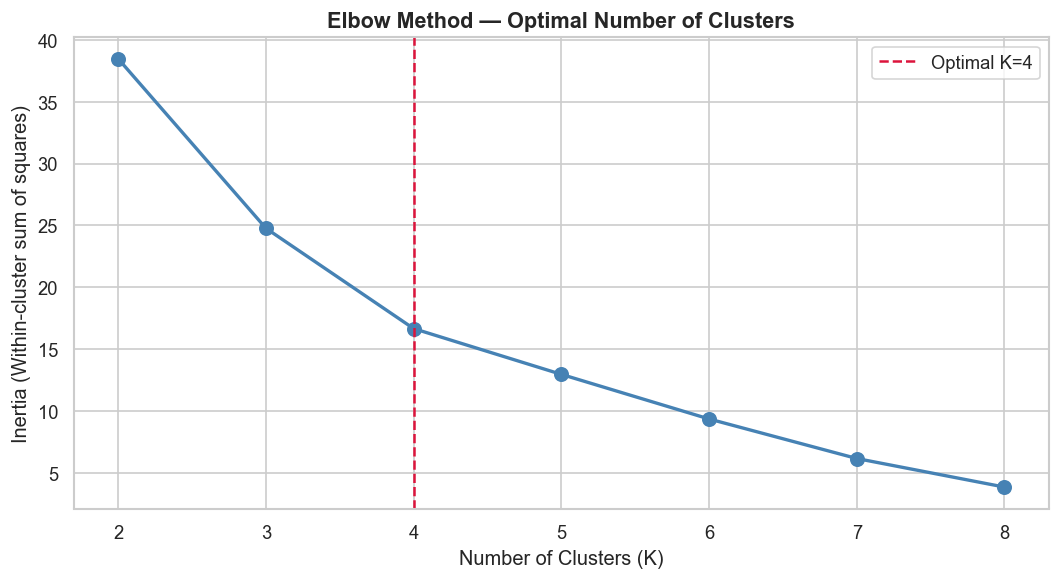

✅ Elbow chart saved → charts/chart8_elbow.png

✅ K-Means fitted with K=4

📋 Sub-categories per cluster:

   Cluster 0: ['Appliances', 'Art', 'Labels', 'Paper']
   Avg TotalSales : $    55,125
   Avg YoY Growth :       44.3%
   Avg Volatility :        850
   Avg Order Value: $        88

   Cluster 1: ['Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Supplies']
   Avg TotalSales : $    53,715
   Avg YoY Growth :       -0.5%
   Avg Volatility :      1,166
   Avg Order Value: $       186

   Cluster 2: ['Copiers', 'Machines']
   Avg TotalSales : $   167,743
   Avg YoY Growth :        6.8%
   Avg Volatility :      5,180
   Avg Order Value: $     1,931

   Cluster 3: ['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']
   Avg TotalSales : $   239,496
   Avg YoY Growth :       25.0%
   Avg Volatility :      3,489
   Avg Order Value: $       361


In [24]:
# ─── Cell 29: Elbow Method + K-Means Clustering ─────────────────────────────

# Scale features — K-Means is distance-based so scale matters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow Method — find optimal number of clusters
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, marker='o', color='steelblue',
        linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster sum of squares)')

# Highlight optimal K
ax.axvline(x=4, color='crimson', linestyle='--',
           linewidth=1.5, label='Optimal K=4')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart8_elbow.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Elbow chart saved → charts/chart8_elbow.png')

# Fit final K-Means with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
features['Cluster'] = km_final.fit_predict(X_scaled)

print(f'\n✅ K-Means fitted with K=4')
print(f'\n📋 Sub-categories per cluster:')
for cluster in sorted(features['Cluster'].unique()):
    members = features[features['Cluster']==cluster].index.tolist()
    print(f'\n   Cluster {cluster}: {members}')
    stats = features[features['Cluster']==cluster][
        ['TotalSales','YoYGrowth','Volatility','AvgOrderVal']].mean()
    print(f'   Avg TotalSales : ${stats["TotalSales"]:>10,.0f}')
    print(f'   Avg YoY Growth : {stats["YoYGrowth"]:>10.1f}%')
    print(f'   Avg Volatility : {stats["Volatility"]:>10,.0f}')
    print(f'   Avg Order Value: ${stats["AvgOrderVal"]:>10,.0f}')

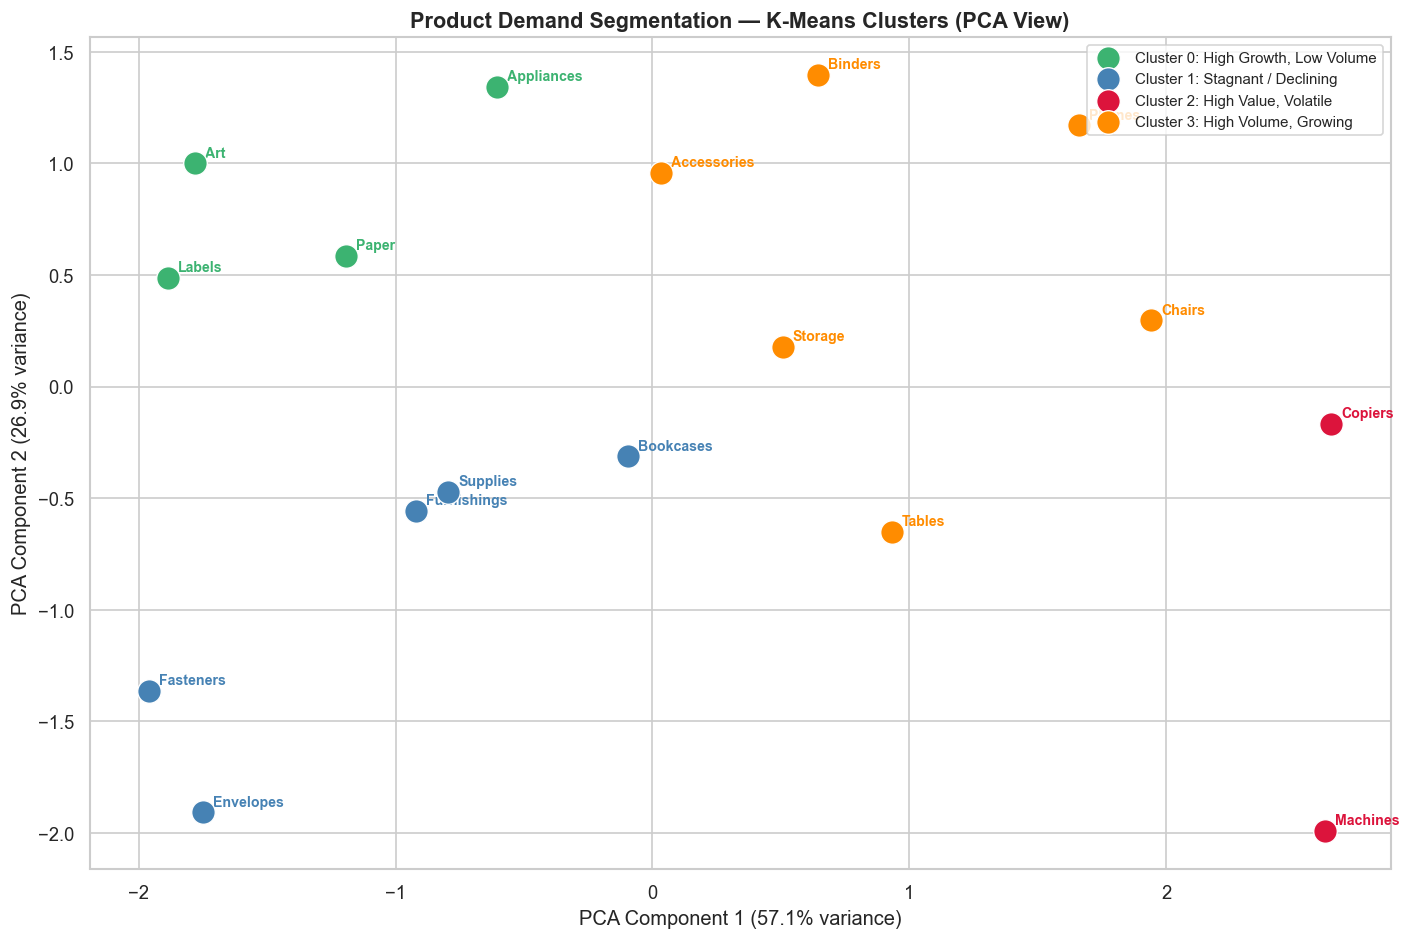

✅ Chart 9 saved → charts/chart9_clusters_pca.png

📊 Cluster Summary:
Cluster Label                        Sub-Categories
--------------------------------------------------------------------------------
0     High Growth, Low Volume      Appliances, Art, Labels, Paper
1     Stagnant / Declining         Bookcases, Envelopes, Fasteners, Furnishings, Supplies
2     High Value, Volatile         Copiers, Machines
3     High Volume, Growing         Accessories, Binders, Chairs, Phones, Storage, Tables


In [25]:
# ─── Cell 30: PCA Visualization + Cluster Labels ────────────────────────────

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Meaningful cluster labels based on stats
cluster_labels = {
    0: 'High Growth, Low Volume',
    1: 'Stagnant / Declining',
    2: 'High Value, Volatile',
    3: 'High Volume, Growing'
}

features['ClusterLabel'] = features['Cluster'].map(cluster_labels)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = {0:'mediumseagreen', 1:'steelblue', 2:'crimson', 3:'darkorange'}

for cluster, label in cluster_labels.items():
    mask = features['Cluster'] == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster], s=200,
               label=f'Cluster {cluster}: {label}',
               zorder=5, edgecolors='white', linewidth=0.8)
    # Annotate each point with sub-category name
    for idx, (i, row) in enumerate(features[mask].iterrows()):
        ax.annotate(i,
                    xy=(X_pca[mask][idx, 0], X_pca[mask][idx, 1]),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=8.5, fontweight='bold',
                    color=colors[cluster])

ax.set_title('Product Demand Segmentation — K-Means Clusters (PCA View)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('charts/chart9_clusters_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart 9 saved → charts/chart9_clusters_pca.png')

# Final summary table
print(f'\n📊 Cluster Summary:')
print(f'{"Cluster":<5} {"Label":<28} {"Sub-Categories"}')
print('-'*80)
for cluster, label in cluster_labels.items():
    members = features[features['Cluster']==cluster].index.tolist()
    print(f'{cluster:<5} {label:<28} {", ".join(members)}')

### 📝 Product Demand Segmentation — Observations & Stocking Strategy

#### Cluster Summary
| Cluster | Label                  | Sub-Categories                                      | Avg Growth | Avg Volatility |
|---------|------------------------|-----------------------------------------------------|------------|----------------|
| 0       | High Growth, Low Volume| Appliances, Art, Labels, Paper                      | +44.3%     | Low (850)      |
| 1       | Stagnant / Declining   | Bookcases, Envelopes, Fasteners, Furnishings, Supplies | -0.5%   | Low (1,166)    |
| 2       | High Value, Volatile   | Copiers, Machines                                   | +6.8%      | Very High (5,180)|
| 3       | High Volume, Growing   | Accessories, Binders, Chairs, Phones, Storage, Tables | +25.0%  | High (3,489)   |

#### Stocking Strategy per Cluster

**Cluster 0 — High Growth, Low Volume (Appliances, Art, Labels, Paper)**
These products are growing fast (+44.3% YoY) but have low sales volume 
and low volatility — demand is predictable. Strategy: **Gradually increase 
stock levels quarter by quarter** to match growth trajectory. Low risk of 
overstock since demand is stable and rising.

**Cluster 1 — Stagnant / Declining (Bookcases, Envelopes, Fasteners, 
Furnishings, Supplies)**
Near-zero or negative YoY growth (-0.5%) with low volatility — these 
products are in mature or declining demand. Strategy: **Maintain lean 
inventory — do not increase stock levels.** Consider promotional pricing 
to clear slow-moving items like Envelopes and Fasteners. Review product 
range for potential discontinuation.

**Cluster 2 — High Value, Volatile (Copiers, Machines)**
Very high average order value ($1,931) but extremely volatile demand 
(std dev = 5,180) — these are large infrequent orders that are hard to 
predict. Strategy: **Do not hold large standing inventory.** Instead use 
a just-in-time (JIT) or made-to-order approach. A single large corporate 
order can spike sales dramatically — maintain supplier relationships for 
rapid restocking.

**Cluster 3 — High Volume, Growing (Accessories, Binders, Chairs, 
Phones, Storage, Tables)**
The core revenue drivers — highest total sales ($239K avg) with strong 
25% growth and manageable volatility. Strategy: **Prioritize these in 
inventory planning.** Maintain 6-8 weeks of safety stock, especially 
going into Q4. These are the products most at risk of stockout during 
the November anomaly spikes we detected in Task 5.

#### Key Business Takeaway
Resources should flow toward Cluster 3 (volume + growth) and Cluster 0 
(high growth potential). Cluster 1 needs a strategic review. Cluster 2 
needs supplier agility, not warehouse space.